In [24]:
!pip install -q -U trl peft transformers datasets accelerate

In [25]:
import torch
from trl import GRPOTrainer, GRPOConfig
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

CUDA: True
Device: Tesla T4


In [26]:
!pip freeze | grep -E '^(trl|transformers|peft|datasets|accelerate)='

accelerate==1.14.0
datasets==5.0.0
peft==0.19.1
transformers==5.13.0
trl==1.8.0


In [27]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
def to_prompt(question: str) -> str:
	msgs = [{
		"role": "user", "content": question
    }]

	return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

def make_arithmetic_dataset(n_samples: int = 200, seed: int = 42):
    import random
    random.seed(seed)
    dataset = []
    for _ in range(n_samples//2):
        a = random.randint(1, 100)
        b = random.randint(1, 100)

        question = f"What is {a} + {b}? Put ONLY the final number inside <answer></answer> tags."
        question_subtraction = f"What is {a} - {b}? Put ONLY the final number inside <answer></answer> tags."

        answer = str(a + b)
        answer_subtraction = str(a - b)

        prompt = to_prompt(question)
        prompt_subtraction = to_prompt(question_subtraction)

        dataset.append({"prompt": prompt, "answer": answer})
        dataset.append({"prompt": prompt_subtraction, "answer": answer_subtraction})

    return dataset

In [28]:
dataset = make_arithmetic_dataset(n_samples=200, seed=42)
print(dataset[:5])

[{'prompt': '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 82 + 15? Put ONLY the final number inside <answer></answer> tags.<|im_end|>\n<|im_start|>assistant\n', 'answer': '97'}, {'prompt': '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 82 - 15? Put ONLY the final number inside <answer></answer> tags.<|im_end|>\n<|im_start|>assistant\n', 'answer': '67'}, {'prompt': '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 4 + 95? Put ONLY the final number inside <answer></answer> tags.<|im_end|>\n<|im_start|>assistant\n', 'answer': '99'}, {'prompt': '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 4 - 95? Put ONLY the final number inside <answer></answer> tags.<|im_end|>\n<|im_start|>

In [51]:
def arithmetic_reward(completions: list[str], answer: list[str], **kwargs) -> list[float]:
    correct = []
    for i, completion in enumerate(completions):
        if "<answer>" in completion and "</answer>" in completion:
            start = completion.index("<answer>") + len("<answer>")
            end = completion.index("</answer>")
            extracted_answer = completion[start:end].strip()
            correct.append(1.0 if extracted_answer == answer[i] else 0.0)
        else:
            correct.append(0.0)
    return correct

In [59]:
from peft import LoraConfig
lora = LoraConfig(r=16, lora_alpha=32, target_modules="all-linear", task_type="CAUSAL_LM")

cfg = GRPOConfig(
    output_dir="grpo-phase0",
    fp16=True, bf16=False,          # T4: fp16 only
    use_vllm=False,                 # Task 0a uses HF generation; vLLM comes in 0b
    logging_steps=1,
    report_to="none",
    max_completion_length=64,
    # ---- ✍️ RL knobs: YOU set these (guidance below) ----
    num_generations=8,            # G: the group whose mean is the advantage baseline
    beta=0.04,                       # KL-to-reference coefficient (the drift leash)
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    num_train_epochs=1,
)


In [53]:
!pip install --upgrade "torchao>=0.16.0"

In [62]:
trainer = GRPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    reward_funcs=[arithmetic_reward],
	args=cfg,
	train_dataset=make_arithmetic_dataset(n_samples=200, seed=42),
    peft_config=lora,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

NameError: name 'LLM' is not defined

In [ ]:
trainer.train()

array([<Axes: xlabel='step'>, <Axes: xlabel='step'>,
       <Axes: xlabel='step'>], dtype=object)

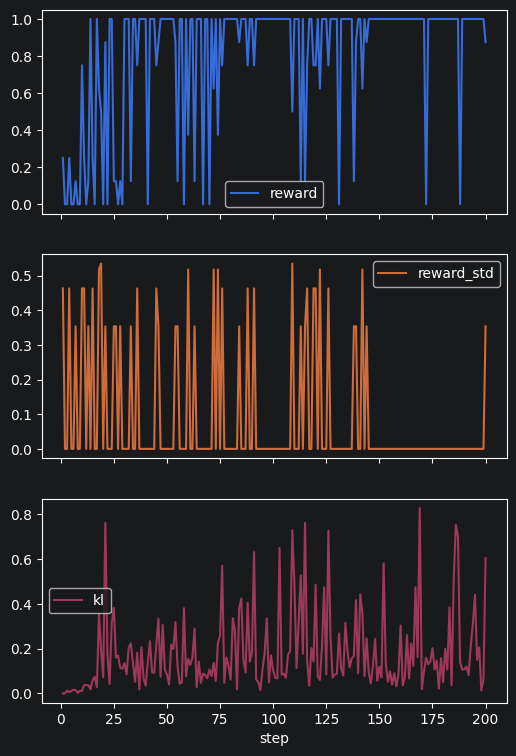

In [56]:
import pandas as pd
hist = pd.DataFrame(trainer.state.log_history)
cols = [c for c in ['reward', 'reward_std', 'kl', 'completion_length'] if c in hist.columns]
hist.dropna(subset=cols[:1])[['step'] + cols].plot(x='step', subplots=True, figsize=(6, 9))

<Axes: xlabel='step'>

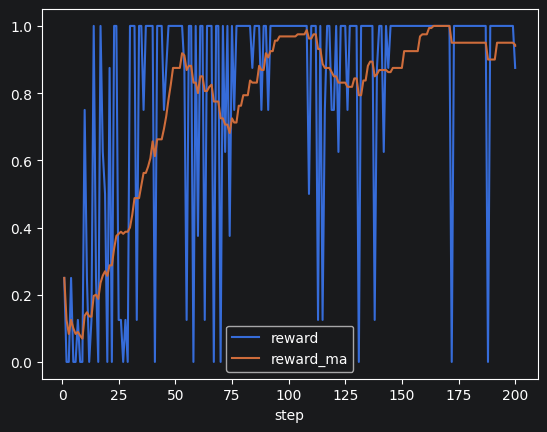

In [57]:
hist['reward_ma'] = hist['reward'].rolling(20, min_periods=1).mean()
hist.plot(x='step', y=['reward', 'reward_ma'])

In [58]:
import numpy as np, torch
model = trainer.model; model.eval()

ev = make_arithmetic_dataset(n_samples=40, seed=999)     # fresh, unseen
prompts, answers = [r["prompt"] for r in ev], [r["answer"] for r in ev]

def gen(use_adapter: bool):
    outs = []
    for p in prompts:
        ids = tok(p, return_tensors="pt").to(model.device)
        with torch.no_grad():
            if use_adapter:
                out = model.generate(**ids, max_new_tokens=64, do_sample=False)
            else:
                with model.disable_adapter():                 # base behavior
                    out = model.generate(**ids, max_new_tokens=64, do_sample=False)
        outs.append(tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True))
    return outs

print("base   :", np.mean(arithmetic_reward(gen(False), answer=answers)))
print("trained:", np.mean(arithmetic_reward(gen(True),  answer=answers)))

base   : 0.25
trained: 0.9


In [45]:
print(prompts[0])
print("\n")
print(answers[0])

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is 87 + 11? Put ONLY the final number inside <answer></answer> tags.<|im_end|>
<|im_start|>assistant



98
